In [ ]:
import tensorflow as tf
import keras  as keras
import numpy as np
import matplotlib.pyplot as plt
import cv2


print(tf.__version__)
print(keras.__version__)
tf.config.list_physical_devices()
# print(tf.config.list_physical_devices('GPU'))

2.21.0
3.15.0


[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

In [3]:
digits_mnist = keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) =  digits_mnist.load_data(path="mnist.npz")
train_images = train_images / 255.0
test_images  = test_images / 255.0

train data:
(60000, 28, 28)
60000
test data:
(10000, 28, 28)
10000
0.0
1.0


array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

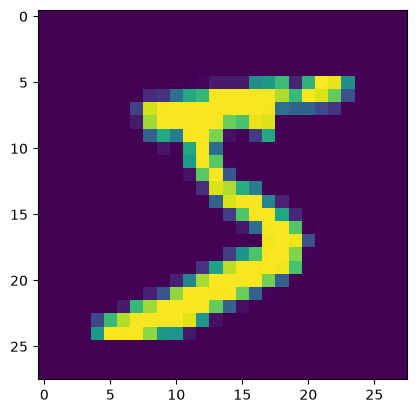

In [69]:
print("train data:")
print(train_images.shape)
print(len(train_images))

print("test data:")
print(test_images.shape)
print(len(test_images))

# this show the data after normalization, it should be in 0.0 , 1.0
print(train_images.min())
print(train_images.max())

display(np.unique(train_labels))
plt.imshow(train_images[0])

In [102]:
model = keras.Sequential([
  keras.layers.Flatten(input_shape = (28,28)),
  keras.layers.Dense(128, activation = 'relu'),
  keras.layers.Dropout(0.3),
  keras.layers.Dense(10, activation = 'softmax')
])

model.compile(
  optimizer = keras.optimizers.Adam(learning_rate = 0.01),
  loss = 'sparse_categorical_crossentropy',
  metrics = ['accuracy']
)

model.summary()

history = model.fit(train_images, train_labels, batch_size=32, validation_data=(test_images, test_labels), epochs=10)

/home/sothea/miniconda3/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_9 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8898 - loss: 0.3713 - val_accuracy: 0.9386 - val_loss: 0.2232
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9166 - loss: 0.2965 - val_accuracy: 0.9462 - val_loss: 0.1973
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9232 - loss: 0.2805 - val_accuracy: 0.9538 - val_loss: 0.1891
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9290 - loss: 0.2649 - val_accuracy: 0.9566 - val_loss: 0.1700
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9313 - loss: 0.2626 - val_accuracy: 0.9480 - val_loss: 0.2130
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9349 - loss: 0.2494 - val_accuracy: 0.9584 - val_loss: 0.1916
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9379 - loss: 0.2450 - val_accuracy: 0.9540 - val_loss: 0.2255
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9375 - loss: 0.2394 - 

In [103]:
model.save("mnist_model.keras")

In [101]:
def plot(history):
  plt.figure(figsize = (10, 5))
  # plt.title("Acc - Val_acc")
  plt.subplot(1, 2, 1)
  plt.title("Acc - Val_acc")
  plt.plot(history.history['accuracy'])
  plt.plot(history.history['val_accuracy'])
  plt.legend(['accuracy', 'val_accuracy'])
  plt.grid()

  # plt.title("Loss - Val_loss")
  plt.subplot(1, 2, 2)
  plt.title("Loss - Val_loss")
  plt.plot(history.history['loss'])
  plt.plot(history.history['val_loss'])
  plt.legend(['loss', 'val_loss'])
  plt.grid()
  plt.tight_layout()
  plt.show()

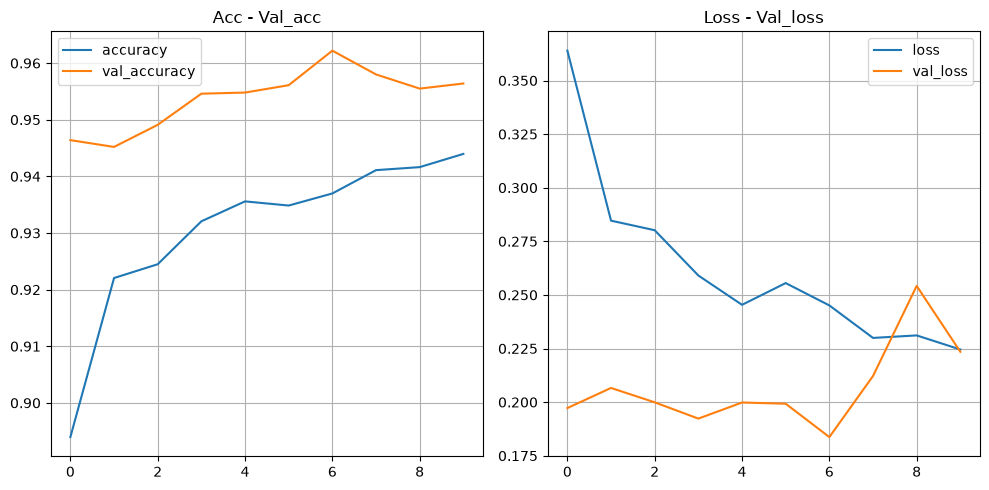

In [32]:
plot(history)

In [39]:
class_name = [
  '0',
  '1',
  '2',
  '3',
  '4',
  '5',
  '6',
  '7',
  '8',
  '9'
]

[0 1 2 3 4 5 6 7 8 9]
[ 85 126 116 107 110  87  87  99  89  94]


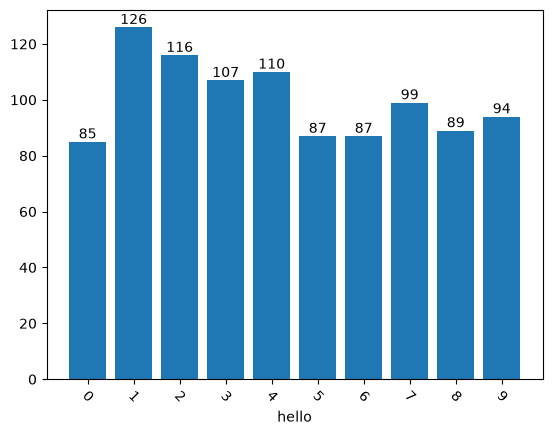

In [43]:
classes, counts = np.unique(test_labels[:1000], return_counts = True)
print(classes)
print(counts)
bars = plt.bar(class_name, counts)
plt.bar_label(bars)

# plt.bar(classes, counts)
plt.xlabel("hello")
plt.xticks(rotation = -45)
plt.show()

In [56]:
prediction = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [60]:
def plot_image(i, predictions_array, true_label, img):
    predictions_array, true_label, img = predictions_array[i], true_label[i], img[i]
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img, cmap='gray')

    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel(
        "{} {:2.0f}% (true: {})".format(
            class_name[predicted_label],
            100 * np.max(predictions_array),
            class_name[true_label],
        ),
        color = color,
    )

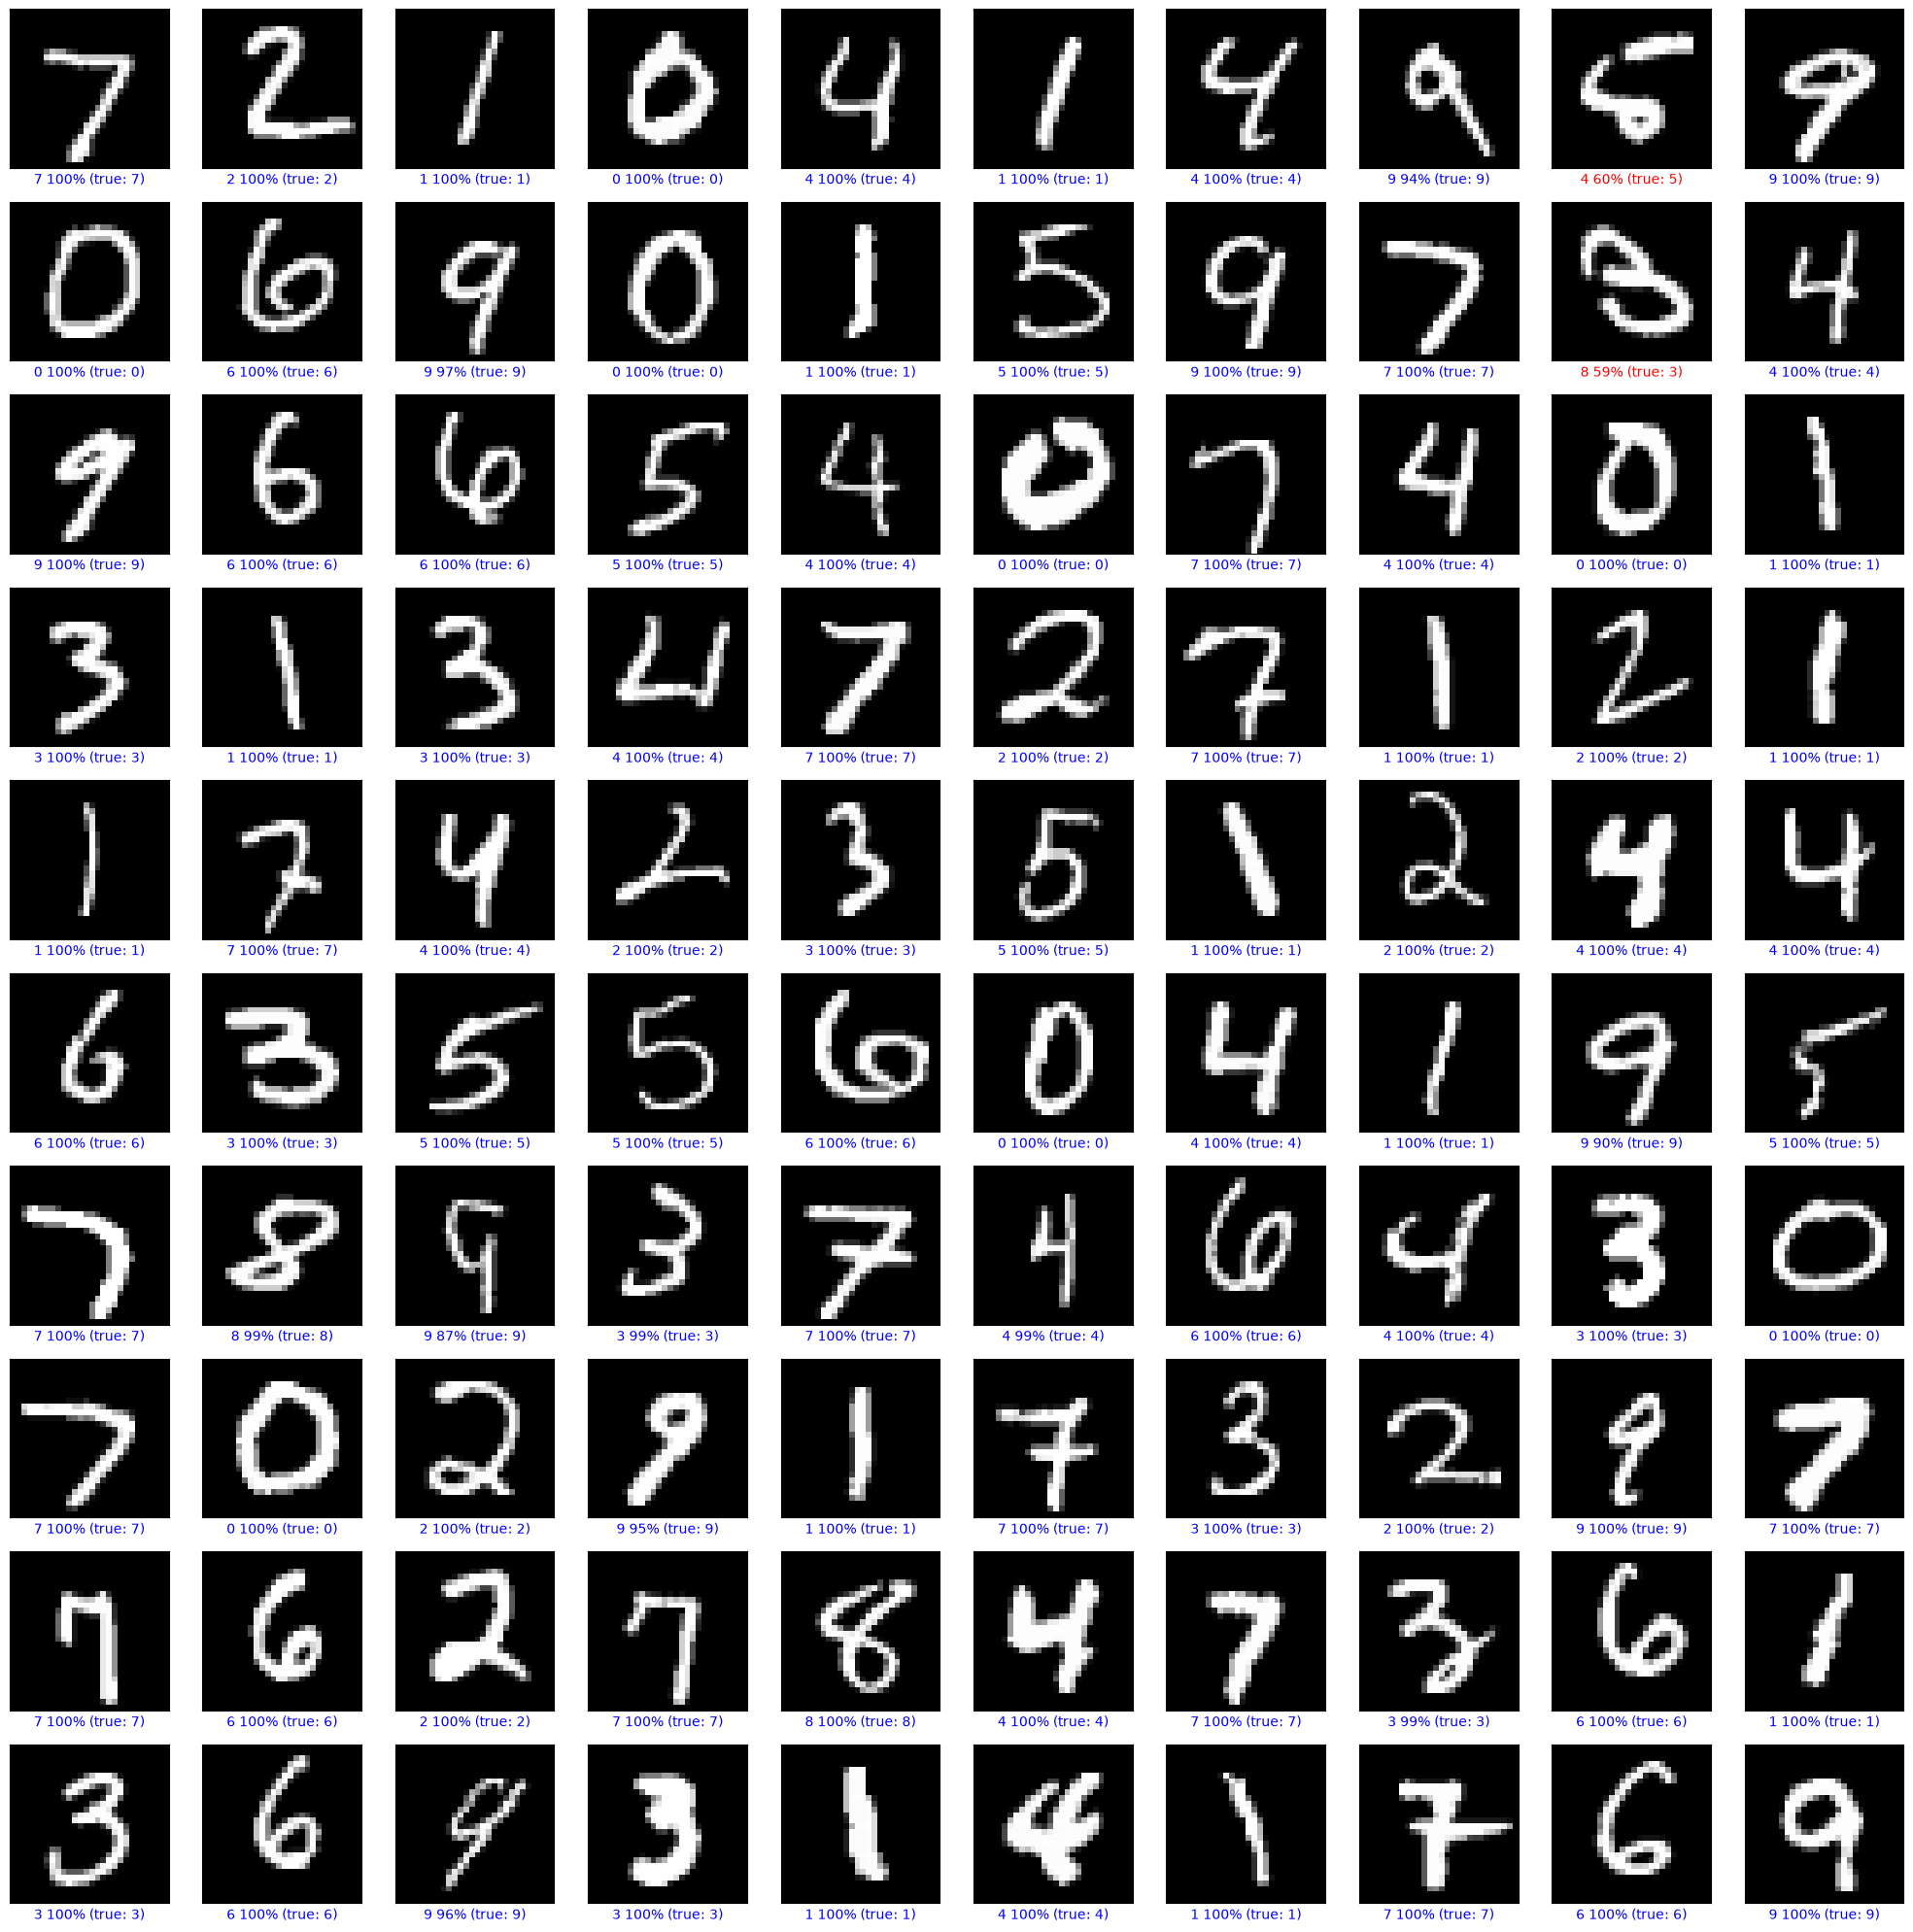

In [70]:
plt.figure(figsize=(20, 20)) 

for i in range(100):
    plt.subplot(10, 10, i+1)
    plot_image(i, prediction, test_labels, test_images)

plt.tight_layout()
plt.show()

In [94]:
file1 = 'imagesFolder/number1_with_circle.png'

test_img1 = cv2.imread(file1)
# plt.imshow(test_img1)
# print(test_img1)

test_img1 = cv2.imread(file1, cv2.IMREAD_GRAYSCALE)

# Resize to 28x28 (MNIST's size)
test_img1 = cv2.resize(test_img1, (28, 28))
test_img1 = 255 - test_img1

# Normalize to 0-1, same as training data
test_img1 = test_img1 / 255.0

test_img1_input = test_img1.reshape(1, 28, 28)

In [77]:
print(test_img1.min())
print(test_img1.max())

0.0
1.0


([], [])

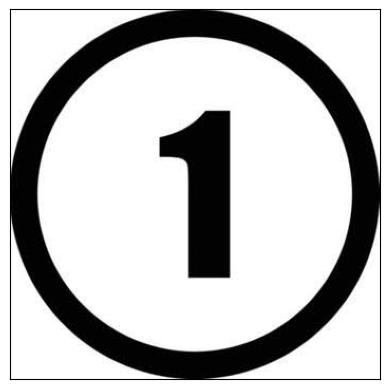

In [80]:
plt.imshow(test_img1)
plt.xticks([])
plt.yticks([])

In [95]:
prediction = model.predict(test_img1_input)
predicted_digit = np.argmax(prediction)
confidence = np.max(prediction) * 100

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


In [96]:
print(f"Predicted digit: {predicted_digit} ({confidence:.1f}% confidence)")

Predicted digit: 5 (100.0% confidence)


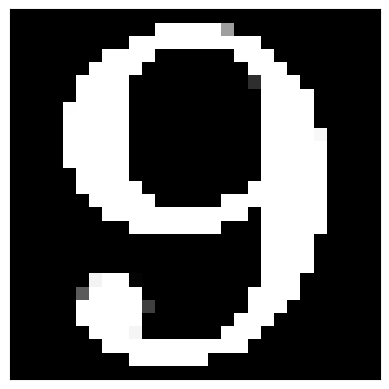

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
[[3.3535582e-21 1.0343820e-03 2.8335480e-15 3.4348744e-09 4.5843231e-03
  6.4398998e-01 1.9171439e-14 3.5039136e-01 6.7727726e-09 5.4823051e-15]]
Predicted digit: 5 (64.4% confidence)


In [99]:
file2 = 'imagesFolder/number9.png'

test_img1 = cv2.imread(file2, cv2.IMREAD_GRAYSCALE)
test_img1 = cv2.resize(test_img1, (28, 28))
test_img1 = 255 - test_img1
test_img1 = test_img1 / 255.0

test_img1_input = test_img1.reshape(1, 28, 28)

plt.imshow(test_img1, cmap='gray')
plt.xticks([])
plt.yticks([])
plt.show()

predict1 = model.predict(test_img1_input)

print(predict1)

predicted_digit = np.argmax(predict1)
confidence = np.max(predict1) * 100
print(f"Predicted digit: {predicted_digit} ({confidence:.1f}% confidence)")

it can't predict because of limitation of our models, learn more to make it better
